Stochastic Gradient Descent function

$w = (\hat{y}_i - y_i)x_i$


$b = (\hat{y}_i - y_i)$

$wight =wight + w*learingrate$

$bias= b*learingrate$

importing libery


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Data set Download

In [2]:
!wget https://raw.githubusercontent.com/codebasics/deep-learning-keras-tf-tutorial/master/7_nn_from_scratch/insurance_data.csv

--2026-04-20 10:15:01--  https://raw.githubusercontent.com/codebasics/deep-learning-keras-tf-tutorial/master/7_nn_from_scratch/insurance_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 231 [text/plain]
Saving to: ‘insurance_data.csv’

insurance_data.csv  100%[===================>]     231  --.-KB/s    in 0s      

2026-04-20 10:15:02 (14.8 MB/s) - ‘insurance_data.csv’ saved [231/231]



In [3]:
df = pd.read_csv("insurance_data.csv")
df.head()

,age,affordibility,bought_insurance
0,22,1,0
1,25,0,0
2,47,1,1
3,52,0,0
4,46,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               28 non-null     int64
 1   affordibility     28 non-null     int64
 2   bought_insurance  28 non-null     int64
dtypes: int64(3)
memory usage: 804.0 bytes


In [11]:
df['age']=df['age']/df['age'].max()

In [25]:
X = df.drop('bought_insurance', axis=1).values
y = df['bought_insurance'].values

Sigmoid activation function

$\sigma(x) = \frac{1}{1 + e^{-x}}$

In [13]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

Standar Deviation

$SDT = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$

In [14]:
def standardize(x):
  return (x - x.mean()) / x.std()

Log Loss Function

$L = - \frac{1}{n} \sum_{i=1}^{n}\left[ y_i \log(p_i) + (1 - y_i)\log(1 - p_i) \right]$

In [15]:
def Log_loss(y_test,y_predicted):
  epsilon=1e-15
  y_predicted_new = np.maximum(y_predicted,epsilon)
  y_predicted_new = np.minimum(y_predicted_new,1-epsilon)
  return -np.mean(y_test*np.log(y_predicted_new)+(1-y_test)*np.log(1-y_predicted_new))

Stochastic Gradient Descent function

$w = (\hat{y}_i - y_i)x_i$


$b = (\hat{y}_i - y_i)$

$wight =wight + w*learingrate$

$bias= b*learingrate$

In [111]:
def sgd(X, y, epochs=500, lr=0.01):

    # Standardize features
    X = (X - X.mean(axis=0)) / X.std(axis=0)

    n_samples, n_features = X.shape

    # Initialize parameters
    weights = np.random.rand(n_features)
    bias = 0

    losses, accuracies, epoch_list = [], [], []

    for epoch in range(epochs):

        # Shuffle data (important for SGD)
        indices = np.random.permutation(n_samples)

        total_loss = 0
        correct = 0

        for i in indices:
            xi = X[i]
            yi = y[i]

            # Forward pass
            linear = np.dot(xi, weights) + bias
            y_pred = 1 / (1 + np.exp(-linear))

            # Loss (single sample)
            epsilon = 1e-15
            y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
            loss = -(yi * np.log(y_pred_clipped) + (1 - yi) * np.log(1 - y_pred_clipped))
            total_loss += loss

            # Gradient
            error = y_pred - yi
            dw = error * xi
            db = error

            # Update
            weights -= lr * dw
            bias -= lr * db

            # Accuracy
            pred_label = 1 if y_pred > 0.5 else 0
            correct += int(pred_label == yi)

        # Epoch metrics
        avg_loss = total_loss / n_samples
        accuracy = correct / n_samples

        losses.append(avg_loss)
        accuracies.append(accuracy)
        epoch_list.append(epoch)

        if epoch % 5 == 0:
            print(f"Epoch {epoch} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

    return weights, bias, losses, accuracies, epoch_list

In [245]:
weights, bias, losses, accuracies, epochs = sgd(X, y, epochs=50, lr=0.3)

Epoch 0 | Loss: 0.4705 | Accuracy: 0.7857
Epoch 5 | Loss: 0.4024 | Accuracy: 0.8929
Epoch 10 | Loss: 0.3994 | Accuracy: 0.8929
Epoch 15 | Loss: 0.4041 | Accuracy: 0.8571
Epoch 20 | Loss: 0.3997 | Accuracy: 0.8929
Epoch 25 | Loss: 0.4014 | Accuracy: 0.8571
Epoch 30 | Loss: 0.3977 | Accuracy: 0.8571
Epoch 35 | Loss: 0.4003 | Accuracy: 0.8571
Epoch 40 | Loss: 0.3980 | Accuracy: 0.8929
Epoch 45 | Loss: 0.3989 | Accuracy: 0.8571


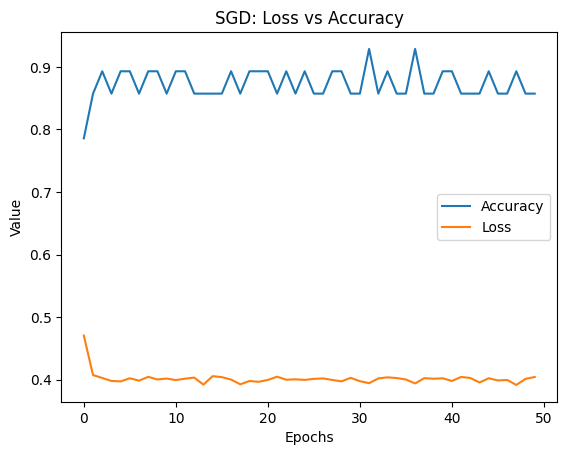

In [246]:
plt.plot(epochs, accuracies, label='Accuracy')
plt.plot(epochs, losses, label='Loss')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('SGD: Loss vs Accuracy')
plt.legend()
plt.show()